**Scrapping Aplikasi Google (H&M)**

by Mirza Fathi Taufiqurrahman
5026231105

**Instalasi Awal**

In [2]:
!pip install google-play-scraper
!pip install nltk
!pip install sastrawi
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


**Collecting Data**

In [3]:
from google_play_scraper import Sort, reviews
import pandas as pd
import time

app_id = 'com.hm.gillcaptital'
all_reviews = []
continuation_token = None

print(f"Memulai unduhan ulasan untuk: {app_id}...")

# Loop untuk mengambil data secara bertahap
for i in range(10):  # Ganti '10' dengan jumlah batch (1 batch = 100 ulasan)
    result, continuation_token = reviews(
        app_id,
        lang='id',          # ganti ke 'en' kalau 'id' sedikit
        sort=Sort.NEWEST,
        count=100,          # Mengambil 100 per up
        continuation_token=continuation_token
    )

    all_reviews.extend(result)
    print(f"Berhasil mengambil {len(all_reviews)} ulasan...")

    time.sleep(1)

    if not continuation_token:
        break

# Simpan ke file
df = pd.DataFrame(all_reviews)
df.to_excel("hasil_ulasan.xlsx", index=False)
print("Selesai! Data disimpan di 'hasil_ulasan.csv'")

Memulai unduhan ulasan untuk: com.hm.gillcaptital...
Berhasil mengambil 100 ulasan...
Berhasil mengambil 200 ulasan...
Berhasil mengambil 300 ulasan...
Berhasil mengambil 400 ulasan...
Berhasil mengambil 500 ulasan...
Berhasil mengambil 600 ulasan...
Berhasil mengambil 700 ulasan...
Berhasil mengambil 800 ulasan...
Berhasil mengambil 900 ulasan...
Berhasil mengambil 1000 ulasan...
Selesai! Data disimpan di 'hasil_ulasan.csv'


**Text Pre-Processing**

In [4]:
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stop_words = set(stopwords.words('indonesian'))
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [stemmer.stem(w) for w in tokens]
    return " ".join(tokens)

df['clean_review'] = df['content'].astype(str).apply(preprocess)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Summary Analysis**

In [5]:
import collections

# 1. Overall
print("\n--- Overall Review Statistics ---")
print(f"Total reviews: {len(df)}")
print(f"Average rating: {df['score'].mean():.2f} out of 5")

# 2. Rating Distribution
print("\n--- Rating Distribution ---")
print(df['score'].value_counts().sort_index(ascending=False))

# 3. Most Frequent Words in Cleaned Reviews
print("\n--- Most Frequent Words in Cleaned Reviews ---")
all_words = ' '.join(df['clean_review']).split()
word_counts = collections.Counter(all_words)

# Display the top 20
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")


--- Overall Review Statistics ---
Total reviews: 1000
Average rating: 3.00 out of 5

--- Rating Distribution ---
score
5    366
4     75
3    109
2     98
1    352
Name: count, dtype: int64

--- Most Frequent Words in Cleaned Reviews ---
aplikasi: 205
nya: 112
lot: 100
bagus: 81
good: 77
ga: 76
banget: 62
gak: 60
barang: 59
yg: 54
belanja: 53
thailand: 51
susah: 46
apk: 46
baik: 42
app: 40
hm: 38
ok: 38
udah: 37
bgt: 36


**Visualisasi**

/tmp/ipykernel_583/3943651871.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=df, palette='viridis', order=sorted(df['score'].unique()))


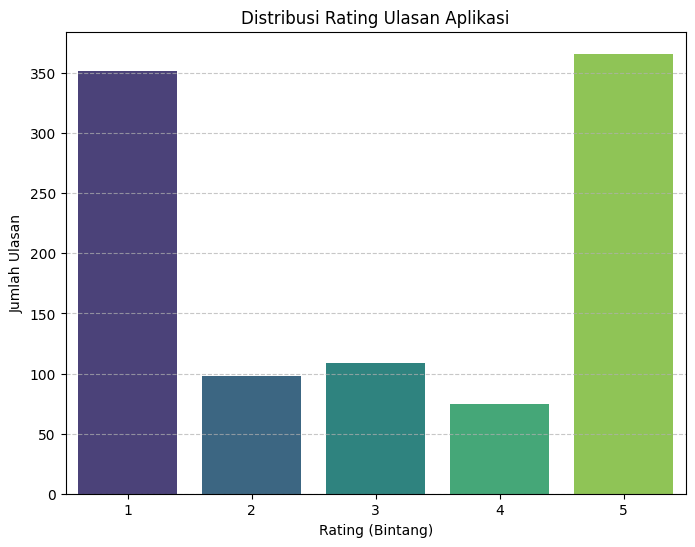

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='score', data=df, palette='viridis', order=sorted(df['score'].unique()), hue='score', legend=False)
plt.title('Distribusi Rating Ulasan Aplikasi')
plt.xlabel('Rating (Bintang)')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualisasi Kata Paling Sering Muncul

/tmp/ipykernel_583/4004446486.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Jumlah', y='Kata', data=top_words_df, palette='magma')


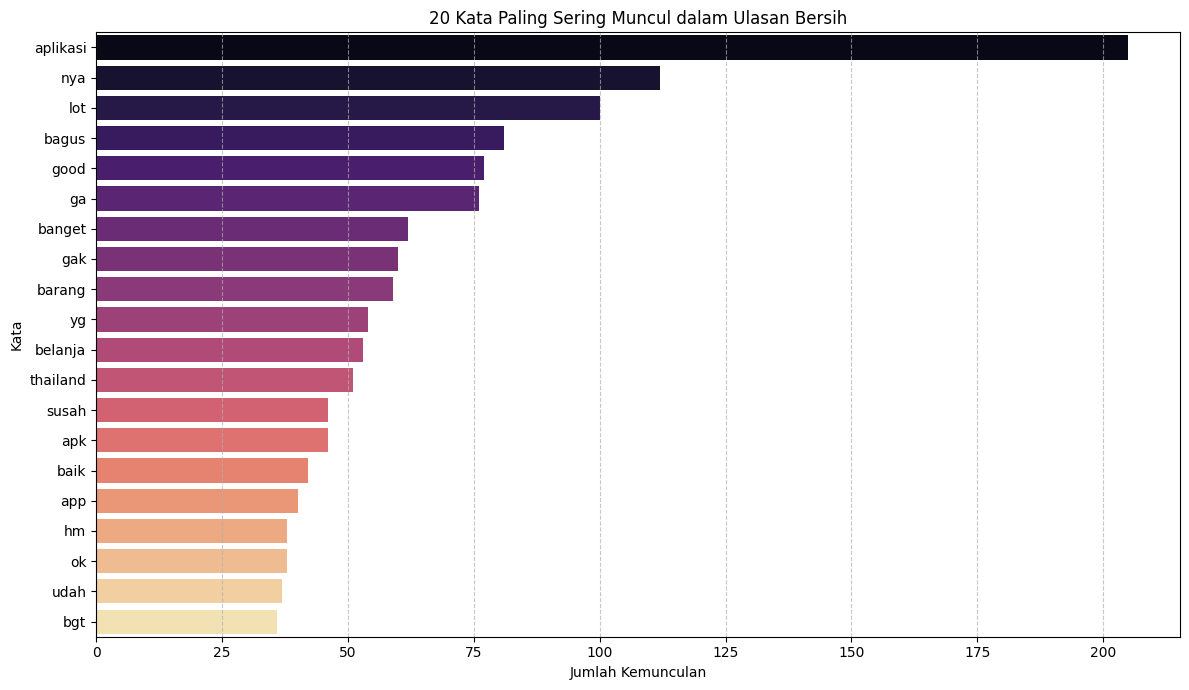

In [7]:
import collections

all_words = ' '.join(df['clean_review']).split()
word_counts = collections.Counter(all_words)

# Ambil 20 kata paling sering muncul
top_words_df = pd.DataFrame(word_counts.most_common(20), columns=['Kata', 'Jumlah'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Jumlah', y='Kata', data=top_words_df, palette='magma', hue='Kata', legend=False)
plt.title('20 Kata Paling Sering Muncul dalam Ulasan Bersih')
plt.xlabel('Jumlah Kemunculan')
plt.ylabel('Kata')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Final**